# Lesson 13: probability distributions

## Outline

1. Probability & random variables
2. Discrete probability distributions
3. Continuous probability distributions
4. PMF vs PDF
5. Bayes' theorem
6. Estimation theory
7. Central limit theorem

## 1. Probability & random variables

**Probability (P)**: number between 0 an 1 that quantifies the likelihood of an event occurring:

$$P(\text{event}) = \frac{\text{Number of ways event can occur}}{\text{Total number of outcomes}}$$

**Random variable**: outcome of a random experiment
- **Discrete** - limited number of outcomes
- **Continuous** - takes any value in some range

In [1]:
import numpy as np

### 1.1. Theoretical probability

In [2]:
events = [1, 2, 3, 4, 5, 6]
p_each = 1 / len(events)

print(f'Probability of rolling a six = {p_each:.2f}')

Probability of rolling a six = 0.17


In [3]:
print(f'Two ones = {(p_each * p_each):.2f}')

Two ones = 0.03


## 1.2. Empirical probability

Estimated probability from an experiment.

In [4]:
trial_sizes = [10, 50, 200, 1000, 10000]

for n in trial_sizes:
    rolls = np.random.randint(1, 7, size=n)
    p_empirical = np.mean(rolls == 6)
    print(f'Empirical p_six = {p_empirical:.4f}')

Empirical p_six = 0.0000
Empirical p_six = 0.1800
Empirical p_six = 0.1650
Empirical p_six = 0.1700
Empirical p_six = 0.1600


## 2. Discrete probability distributions:

- **Bernoulli**: single yes/no trial
- **Binomial**: number successes in n bernoulli trials
- **Poisson**: number of events in a fixed interval

### 2.2. Bernoulli

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import bernoulli

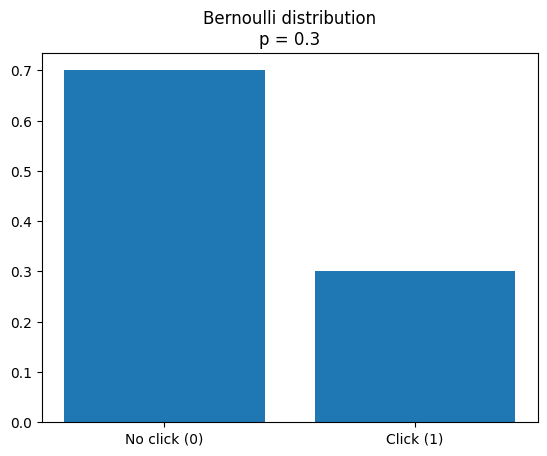

In [6]:
p = 0.3
dist = bernoulli(p)

outcomes = [0, 1]
probs = [dist.pmf(k) for k in outcomes]

plt.title(f'Bernoulli distribution\np = {p}')
plt.bar(['No click (0)', 'Click (1)'], probs)
plt.show()

### 2.3. Binomial distribution

Number of successes in n Bernoulli trials.

In [7]:
from scipy.stats import binom

In [8]:
p, n = 0.9, 10
dist = binom(n, p)

k = np.arange(0, n + 1)
pmf = dist.pmf(k)
probs = [dist.pmf(k) for k in outcomes]

print(f'Mean: {dist.mean():.2f}, std: {dist.std():.2f}')

Mean: 9.00, std: 0.95


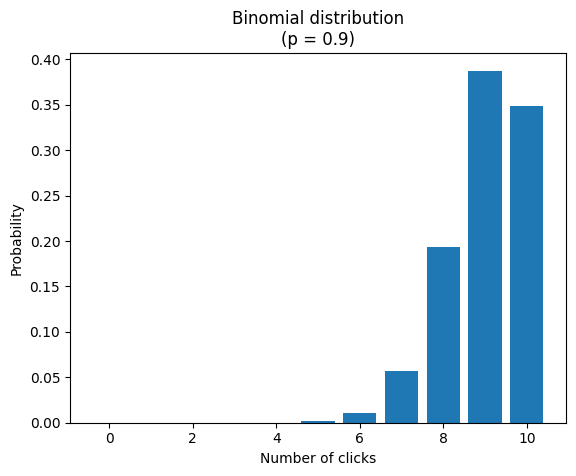

In [9]:
plt.title(f'Binomial distribution\n(p = {p})')
plt.bar(k, pmf)
plt.xlabel('Number of clicks')
plt.ylabel('Probability')
plt.show()

## 3. Continuous distributions

### 3.1. Normal distribution

Normal distribution (gaussian or 'bell curve'):

- **Mean**: center of bell
- **Variance/standard deviation**: width (spread)
- **Symmetric**: mean = median
- **68-95-99.7% rule**: the percent of the data with 1, 2 or 3 standard deviations of the mean

Natural variation often follows normal distribution (ex: people's heigh).

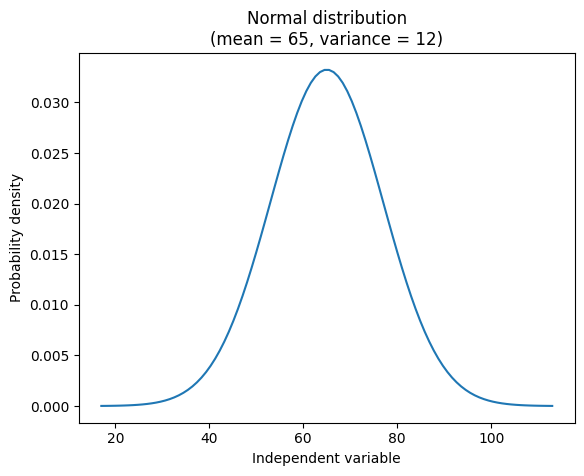

In [ ]:
from scipy.stats import norm

mean, variance = 65, 12
dist = norm(mean, variance)

x = np.linspace(mean - 4*variance, mean + 4*variance, 100)

plt.title(f'Normal distribution\n(mean = {mean}, variance = {variance})')
plt.plot(x, dist.pdf(x))
plt.xlabel('Independent variable')
plt.ylabel('Probability density')
plt.show()

## 4. Probability density function vs probability mass function

|                |   **PMF (probability mass function)**  |  **PDF (probability density function)** |
|----------------|----------------------------------------|-----------------------------------------|
| Variable type  | Discrete (quantized)                   | Continuous                              |
| y-axis meaning | Exact probability                      | Density, no probability itself          |
| How to get probability | Just read y axis               | Compute area under curve between two point |
| Total          | Sums to 1                              | Sums to 1 |

## 5. Bayes' theorem

**Reviews**
1. The food was good - positive 
2. The food was awesome - positive
3. The food was terrible - negative

**Word counts**
- the: 3
- food: 3
- good: 1
- awesome: 1
- terrible: 1
---
- Probability of negative review = 1/3
- Probability of negative review given it contains 'terrible' = 1/1

Bayes' theorem describes how to update a probability estimate when you have more information.

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

| Terms | Name  | Meaning |
|-------|-------|---------|
| $$P(A)$$  | Prior | Your belief about the probability of A before new information |
| $$P(B \mid A)$$| Likelihood | How probable the new evidence B is, give A is true |
| $$P(B)$$ | Marginal likelihood | Probability of B by itself |
| $$P(A \mid B)$$ | Posterior | New probability of A after seeing new information about B |

**Posterior ~ Likelihood * prior**


## 7. Estimation theory

We deal with samples from populations. Have a sample to train model, calculate statistic, etc; want to generalize and understand/predict the population.

| Term | Definition |
|------|------------|
| Population| All examples/observations that exist (almost never have access to whole population)|
| Sample | Subset we have in our dataset |
| Parameter | True value in the population, ex: mean |
| Statistic | Value from a sample ex: mean |
| Point estimate| Single 'best-guess' number |
| Interval estimate| Range of possible/likely values |


## 8. Central limit theorem

When sampling repeatedly from a distribution, the distribution of a sample statistic approaches a normal distribution as the sample size increases, regardless of the original distribution.

In [ ]:
from scipy.stats import gamma

a = 1
dist = gamma(a)

x = np.linspace(0, 20, 10000)

In [ ]:
# Use a loop to sample dist multiple times and find the mean of each sample
# Then, plot the distribution of the means Repeat the procedure for different
# sample sizes and observe the results

sample_sizes = [10, 20, 40, 80, 160]

for sample_size in sample_sizes:
    for i in range(sample_size):

        # Draw sample_size random points from dist

        # Calculate the mean and collect it


In [ ]:
# Plot a histogram of the distribution of means for each sample size